In [12]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import PowerTransformer, StandardScaler

Dataset

In [13]:
df = pd.read_csv('../../data/processed/olist_nlp_dataset.csv')
df.head().T

,0,1,2,3,4
order_id,e481f51cbdc54678b7cc49136f2d6af7,53cdb2fc8bc7dce0b6741e2150273451,949d5b44dbf5de918fe9c16f97b45f8a,136cce7faa42fdb2cefd53fdc79a6098,e6ce16cb79ec1d90b1da9085a6118aeb
customer_id,9ef432eb6251297304e76186b10a928d,b0830fb4747a6c6d20dea0b8c802d7ef,f88197465ea7920adcdbec7375364d82,ed0271e0b7da060a393796590e7b737a,494dded5b201313c64ed7f100595b95c
order_status,delivered,delivered,delivered,invoiced,delivered
order_purchase_timestamp,2017-10-02 10:56:33,2018-07-24 20:41:37,2017-11-18 19:28:06,2017-04-11 12:22:08,2017-05-16 19:41:10
order_approved_at,2017-10-02 11:07:15,2018-07-26 03:24:27,2017-11-18 19:45:59,2017-04-13 13:25:17,2017-05-16 19:50:18
order_delivered_carrier_date,2017-10-04 19:55:00,2018-07-26 14:31:00,2017-11-22 13:39:59,NaN,2017-05-18 11:40:40
order_delivered_customer_date,2017-10-10 21:25:13,2018-08-07 15:27:45,2017-12-02 00:28:42,NaN,2017-05-29 11:18:31
order_estimated_delivery_date,2017-10-18,2018-08-13,2017-12-15,2017-05-09,2017-06-07
order_item_id,1.0,1.0,1.0,1.0,1.0
product_id,87285b34884572647811a353c7ac498a,595fac2a385ac33a80bd5114aec74eb8,d0b61bfb1de832b15ba9d266ca96e5b0,a1804276d9941ac0733cfd409f5206eb,08574b074924071f4e201e151b152b4e


In [14]:
columns = ['order_id','customer_id','order_status','order_purchase_timestamp','order_approved_at',
           'order_delivered_carrier_date','order_delivered_customer_date','order_estimated_delivery_date','order_item_id',
           'product_id','seller_id','shipping_limit_date',
           'product_category_name','product_name_lenght','product_description_lenght','product_photos_qty',
           'customer_unique_id','customer_zip_code_prefix','customer_city','customer_state',
           'review_id','review_comment_title','review_comment_message','review_creation_date','review_answer_timestamp','clean_review','review_length_words']
df.drop(columns=columns, inplace=True)
df.head().T

,0,1,2,3,4
price,29.99,118.70,45.0,49.90,99.00
freight_value,8.72,22.76,27.2,16.05,30.53
product_weight_g,500.00,400.00,450.0,600.00,9000.00
product_length_cm,19.00,19.00,30.0,35.00,42.00
product_height_cm,8.00,13.00,10.0,35.00,12.00
product_width_cm,13.00,19.00,20.0,15.00,39.00
review_score,4.00,4.00,5.0,2.00,1.00
actual_delivery_days,8.00,13.00,13.0,NaN,12.00
delivery_delay_days,-8.00,-6.00,-13.0,NaN,-9.00


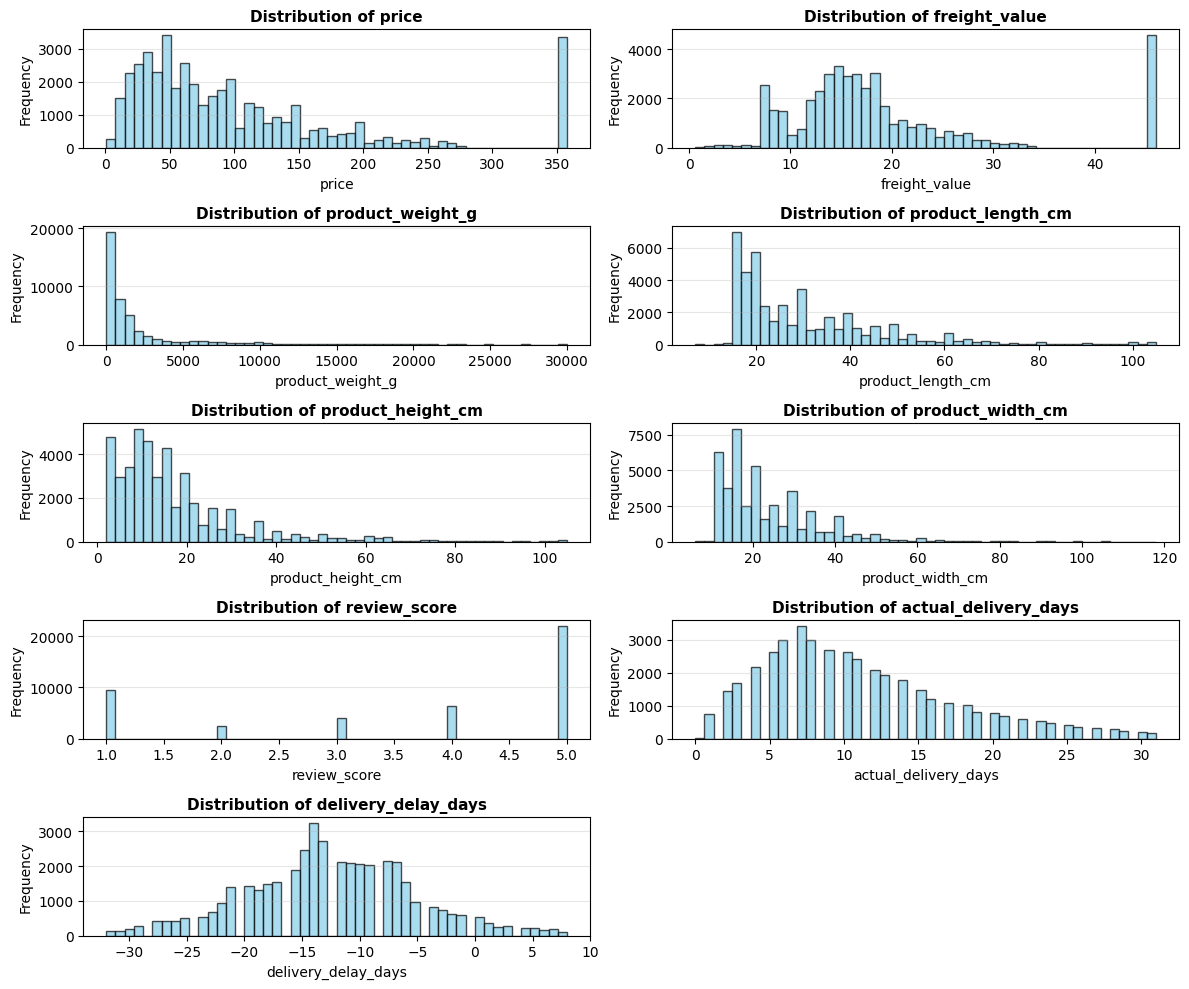

In [15]:
# Create distribution plots for all numerical features
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()

fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.delaxes(axes[-1])
plt.tight_layout()
plt.show()

## Normalization

In [16]:
# Select only numerical columns
numerical_cols = df.select_dtypes(include=[np.number]).columns

target_col = "review_score"
power_cols = [
    c for c in numerical_cols
    if any(sub in c for sub in ["product_length", "product_weight", "product_height", "product_width", "delivery_delay_days"])
]
other_cols = [c for c in numerical_cols if c != target_col and c not in power_cols]

# Apply PowerTransformer to selected product dimension features
pt = PowerTransformer(method="yeo-johnson", standardize=True)
if power_cols:
    df[power_cols] = pt.fit_transform(df[power_cols])

# Apply StandardScaler to remaining numeric features except the target column
scaler = StandardScaler()
if other_cols:
    df[other_cols] = scaler.fit_transform(df[other_cols])

print(f"Power-transformed columns: {power_cols}")
print(f"Standard-scaled columns: {other_cols}")
print(f"Target column kept unscaled: {target_col}")
print(df[[*power_cols, *other_cols, target_col]].describe())

Power-transformed columns: ['product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'delivery_delay_days']
Standard-scaled columns: ['price', 'freight_value', 'actual_delivery_days']
Target column kept unscaled: review_score
       product_weight_g  product_length_cm  product_height_cm  \
count      4.382500e+04       4.382500e+04       4.382500e+04   
mean       1.504583e-16       6.907464e-15      -7.458064e-17   
std        1.000011e+00       1.000011e+00       1.000011e+00   
min       -8.043440e+00      -4.987276e+00      -2.131293e+00   
25%       -7.392925e-01      -9.277674e-01      -6.346923e-01   
50%       -3.544831e-02      -1.832816e-02      -1.329775e-02   
75%        6.613077e-01       8.685329e-01       5.670608e-01   
max        2.261442e+00       2.152384e+00       2.984102e+00   

       product_width_cm  delivery_delay_days         price  freight_value  \
count      4.382500e+04         4.233300e+04  4.383800e+04   4.383800e+04   
mean     

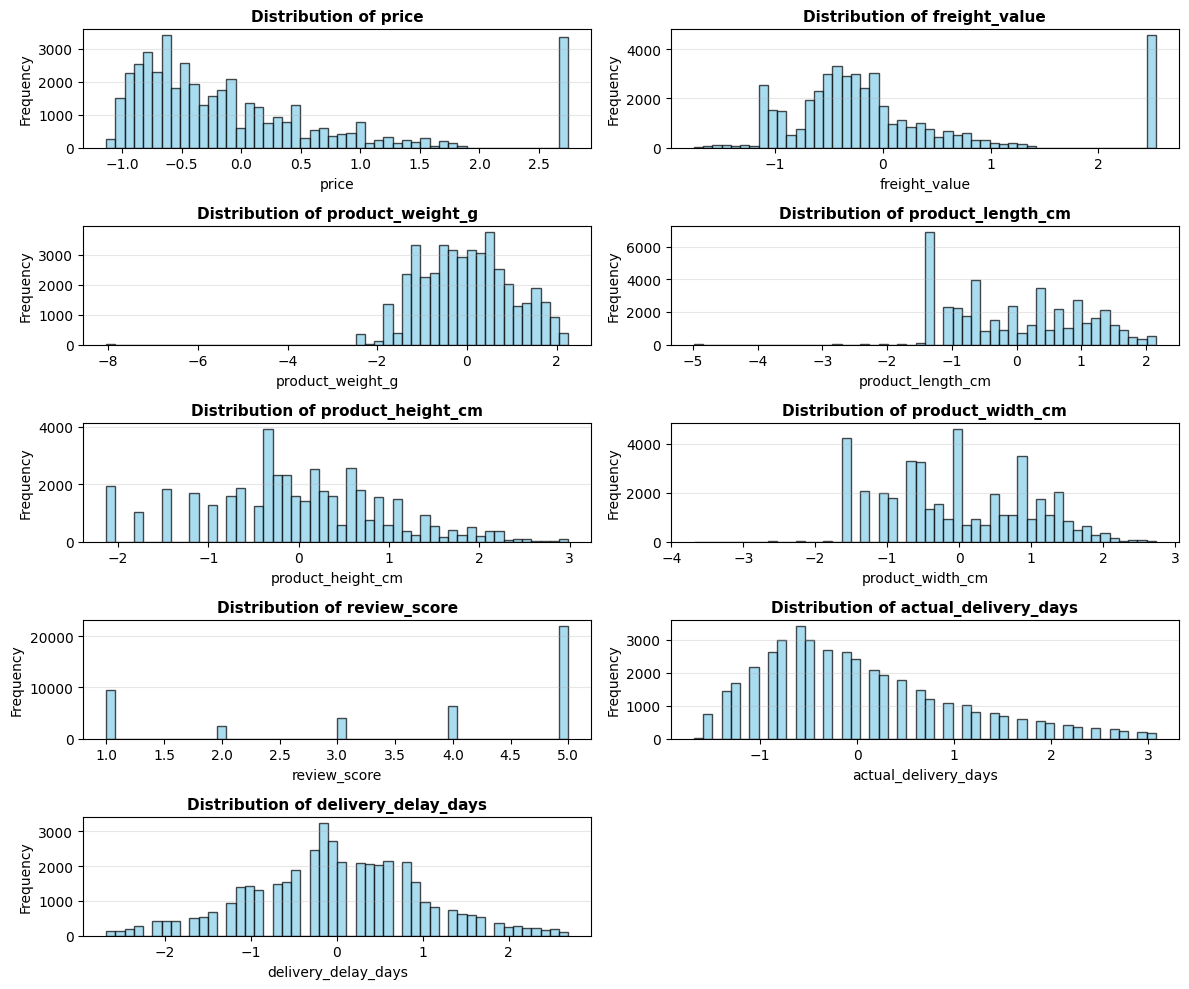

In [17]:
# Create distribution plots for all numerical features
fig, axes = plt.subplots(nrows=5, ncols=2, figsize=(12, 10))
axes = axes.ravel()

for idx, col in enumerate(numerical_cols):
    axes[idx].hist(df[col], bins=50, edgecolor='black', alpha=0.7, color='skyblue')
    axes[idx].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[idx].set_xlabel(col)
    axes[idx].set_ylabel('Frequency')
    axes[idx].grid(axis='y', alpha=0.3)

plt.delaxes(axes[-1])
plt.tight_layout()
plt.show()

In [18]:
df.dropna(inplace=True)
df.isnull().sum()
df.head().T

,0,1,2,4,5
price,-0.816722,0.146691,-0.653710,-0.067256,-0.067256
freight_value,-0.989925,0.335382,0.754496,1.068831,1.068831
product_weight_g,-0.312690,-0.495659,-0.398437,1.639816,1.639816
product_length_cm,-0.763242,-0.763242,0.401394,1.042962,1.042962
product_height_cm,-0.634692,-0.013298,-0.353880,-0.118320,-0.118320
product_width_cm,-1.094456,-0.103471,0.017408,1.340450,1.340450
review_score,4.000000,4.000000,5.000000,1.000000,1.000000
actual_delivery_days,-0.454233,0.313664,0.313664,0.160084,0.160084
delivery_delay_days,0.648005,0.918606,-0.035254,0.512049,0.512049


Saving the dataset for later use in ml models

In [19]:
df.to_csv('../../data/interim/olist_ml_processed_review_dataset.csv', index=False)